In [88]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import random

In [89]:

if torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU (Linux/Windows, not Mac)
else:
    device = torch.device("cpu")   # Fallback
print("Using device:", device)


Using device: cuda


In [156]:
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

# ------------------------
# Transform: scale to [0,1]
# ------------------------
transform = transforms.Compose([
    transforms.ToTensor(),                         
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])  
])

# ------------------------
# Full CIFAR-10 training set (50k)
# ------------------------
trainset_full = torchvision.datasets.CIFAR10(
    root='/home/csalt/Haider/ATML/ATML-PA1/cifar_data', train=True, download=True, transform=transform
)

# ------------------------
# Split into train/val
# Example: 45k for train, 5k for validation
# ------------------------
train_size = int(0.9 * len(trainset_full))   # 45k
val_size   = len(trainset_full) - train_size # 5k
trainset, valset = random_split(trainset_full, [train_size, val_size])

trainloader_cifar = DataLoader(trainset, batch_size=32, shuffle=True,  num_workers=1)
valloader_cifar   = DataLoader(valset,   batch_size=32, shuffle=False, num_workers=1)

# ------------------------
# CIFAR-10 test set (10k)
# ------------------------
testset = torchvision.datasets.CIFAR10(
    root='/home/csalt/Haider/ATML/ATML-PA1/cifar_data', train=False, download=True, transform=transform
)
testloader_cifar = DataLoader(testset, batch_size=32, shuffle=False, num_workers=1)

# ------------------------
# CIFAR-10 classes (for reference)
# ------------------------
classes = ('airplane', 'automobile', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


Files already downloaded and verified
Files already downloaded and verified


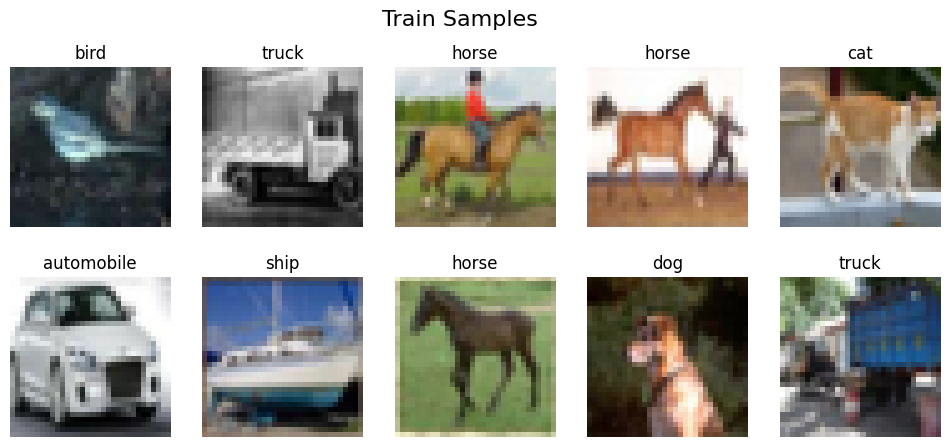

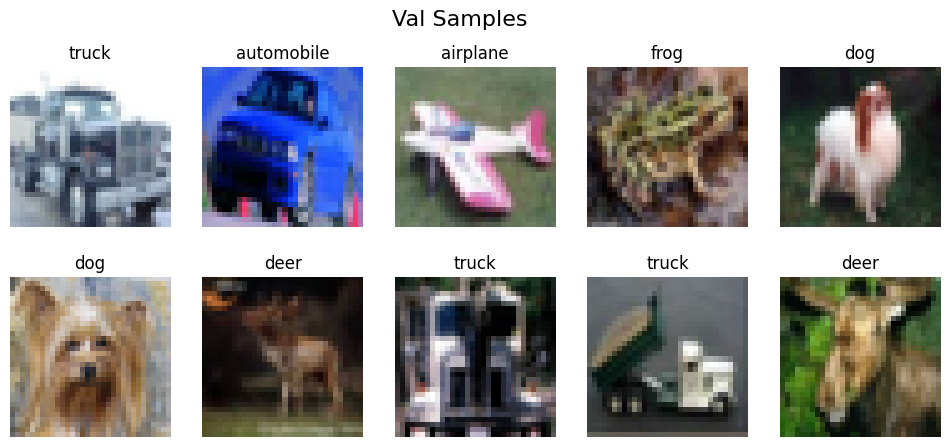

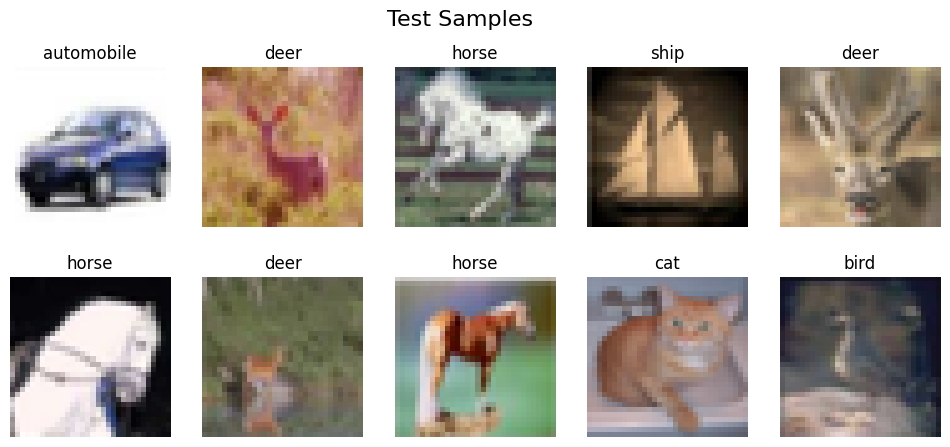

Train samples: 45000
Val samples:   5000
Test samples:  10000


In [92]:
import random
import matplotlib.pyplot as plt

# -----------------------------
# Helper: show images (with de-normalization)
# -----------------------------
def imshow(imgs, labels, title):
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(title, fontsize=16)
    for i, ax in enumerate(axes.flatten()):
        img = imgs[i].numpy().transpose((1, 2, 0))  # C,H,W -> H,W,C

        # De-normalize: x = x*std + mean
        mean = np.array([0.5, 0.5, 0.5])
        std  = np.array([0.5, 0.5, 0.5])
        img = std * img + mean   # back to [0,1]

        img = np.clip(img, 0, 1) # avoid overflow
        ax.imshow(img)
        ax.set_title(classes[labels[i]])
        ax.axis("off")
    plt.show()

# -----------------------------
# Random 10 from each split
# -----------------------------
for subset, name in [(trainset, "Train"), (valset, "Val"), (testset, "Test")]:
    indices = random.sample(range(len(subset)), 10)
    imgs = [subset[i][0] for i in indices]
    labels = [subset[i][1] for i in indices]
    imshow(imgs, labels, f"{name} Samples")

# Print dataset sizes
print(f"Train samples: {len(trainset)}")
print(f"Val samples:   {len(valset)}")
print(f"Test samples:  {len(testset)}")


In [93]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================
#  Blocks (BN always on)
# =========================
def down_block(cin, cout):
    # 2× downsample via stride-2 conv, then a refine conv
    return nn.Sequential(
        nn.Conv2d(cin, cout, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),

        nn.Conv2d(cout, cout, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
    )

def up_block(cin, cout):
    # 2× upsample via NN upsample, then two 3×3 convs
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(cin, cout, kernel_size=3, padding=1),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),

        nn.Conv2d(cout, cout, kernel_size=3, padding=1),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
    )

# =========================
#  Model (4×4 bottleneck)
# =========================
class Encoder(nn.Module):
    """
    32 -> 16 -> 8 -> 4 (H,W)
    Channels: 3 -> C -> 2C -> 4C
    """
    def __init__(self, latent_dim=128, base_ch=64):
        super().__init__()
        C = base_ch
        self.enc = nn.Sequential(
            down_block(3,    C),    # 32 -> 16
            down_block(C,    2*C),  # 16 -> 8
            down_block(2*C,  4*C),  #  8 -> 4
        )
        self.flat_dim  = 4 * C * 4 * 4    # 4C × 4 × 4
        self.fc_mu     = nn.Linear(self.flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_dim, latent_dim)

    def forward(self, x):
        h = self.enc(x)                     # [B, 4C, 4, 4]
        h = h.view(h.size(0), -1)           # [B, 4C*4*4]
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    """
    4 -> 8 -> 16 -> 32 (H,W)
    Channels: 4C -> 4C -> 2C -> C -> 3
    """
    def __init__(self, latent_dim=128, base_ch=64, out_act="tanh"):
        super().__init__()
        C       = base_ch
        self.C  = C
        self.fc = nn.Linear(latent_dim, 4 * C * 4 * 4)

        # BN right after the FC reshape
        self.bn0 = nn.BatchNorm2d(4*C)

        self.up1 = up_block(4*C, 4*C)  # 4 -> 8
        self.up2 = up_block(4*C, 2*C)  # 8 -> 16
        self.up3 = up_block(2*C,   C)  # 16 -> 32

        self.head = nn.Conv2d(C, 3, kernel_size=1)

        if out_act == "tanh":
            self.out_act = nn.Tanh()
        elif out_act == "none":
            self.out_act = nn.Identity()
        else:
            raise ValueError("For [-1,1] Gaussian, use out_act='tanh' or 'none'.")

    def forward(self, z):
        C = self.C
        h = self.fc(z).view(z.size(0), 4*C, 4, 4)
        h = self.bn0(h)
        h = F.relu(h, inplace=True)

        h = self.up1(h)
        h = self.up2(h)
        h = self.up3(h)
        x = self.head(h)
        return self.out_act(x)

class VAE(nn.Module):
    def __init__(self, latent_dim=128, base_ch=64, out_act="tanh"):
        super().__init__()
        self.encoder = Encoder(latent_dim=latent_dim, base_ch=base_ch)
        self.decoder = Decoder(latent_dim=latent_dim, base_ch=base_ch, out_act=out_act)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

# Optional: sensible init
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)


In [17]:
def elbo_loss(x_recon, x, mu, logvar, reduction="mean"):
    """
    Reconstruction and KL computed in the SAME normalized space as x and x_recon (e.g., [-1, 1] if using tanh).
    Returns (total, mse, kl), each reduced per image if reduction=='mean'.
    """
    # Reconstruction MSE
    mse_sum = F.mse_loss(x_recon, x, reduction="sum")

    # KL(q(z|x) || p(z)) for diagonal Gaussians
    kl_sum = 0.5 * torch.sum(mu.pow(2) + logvar.exp() - logvar - 1.0)

    if reduction == "mean":
        B = x.size(0)
        return (mse_sum + kl_sum) / B, mse_sum / B, kl_sum / B
    else:
        return mse_sum + kl_sum, mse_sum, kl_sum

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [ ]:
# -------------------------
# Training loop with KL warm-up
# -------------------------
from tqdm import tqdm
def train_vae(
    model,
    trainloader,
    valloader,
    epochs=50,
    lr=1e-3,
    save_dir="./checkpoints_vae",
    use_tqdm=True,
    leave_train=False,
    leave_val=False,
    kl_target=1.0,        # final beta
    warmup_steps=None,    # if None: min(20k, 40% of total steps)
    clip_grad=None        # e.g., 1.0 to clip by global norm
):
    device = next(model.parameters()).device
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    os.makedirs(save_dir, exist_ok=True)

    # Determine warm-up length in optimizer steps (batches)
    total_steps = epochs * len(trainloader)
    if warmup_steps is None:
        warmup_steps = min(20000, max(1, int(0.4 * total_steps)))

    global_step = 0

    for epoch in range(1, epochs + 1):
        # ==================== Train ====================
        model.train()
        train_loss = train_mse = train_kl = 0.0
        n_train = len(trainloader.dataset)

        it = tqdm(trainloader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=leave_train) if use_tqdm else trainloader

        for imgs, _ in it:
            imgs = imgs.to(device)

            # Linear warm-up of beta to kl_target
            if global_step < warmup_steps:
                beta = kl_target * (global_step / warmup_steps)
            else:
                beta = kl_target

            opt.zero_grad(set_to_none=True)
            x_recon, mu, logvar = model(imgs)
            _, mse, kl = elbo_loss(x_recon, imgs, mu, logvar, reduction="mean")

            loss = mse + beta * kl
            loss.backward()

            if clip_grad is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            opt.step()

            bs = imgs.size(0)
            train_loss += loss.item() * bs
            train_mse  += mse.item()  * bs
            train_kl   += kl.item()   * bs

            global_step += 1

            if use_tqdm:
                it.set_postfix(
                    loss=f"{loss.item():.3f}",
                    mse=f"{mse.item():.3f}",
                    kl=f"{kl.item():.3f}",
                    beta=f"{beta:.3f}"
                )

        train_loss /= n_train
        train_mse  /= n_train
        train_kl   /= n_train

        # ==================== Val ====================
        model.eval()
        val_loss = val_mse = val_kl = 0.0
        n_val = len(valloader.dataset)
        itv = tqdm(valloader, desc=f"Epoch {epoch}/{epochs} [Val]", leave=leave_val) if use_tqdm else valloader

        with torch.no_grad():
            for imgs, _ in itv:
                imgs = imgs.to(device)
                x_recon, mu, logvar = model(imgs)
                _, mse, kl = elbo_loss(x_recon, imgs, mu, logvar, reduction="mean")

                # Evaluate ELBO with the final target beta for consistency
                loss = mse + kl_target * kl

                bs = imgs.size(0)
                val_loss += loss.item() * bs
                val_mse  += mse.item()  * bs
                val_kl   += kl.item()   * bs

                if use_tqdm:
                    itv.set_postfix(loss=f"{loss.item():.3f}", mse=f"{mse.item():.3f}", kl=f"{kl.item():.3f}")

        val_loss /= n_val
        val_mse  /= n_val
        val_kl   /= n_val

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train: {train_loss:.4f} (MSE {train_mse:.4f}, KL {train_kl:.4f}) | "
            f"Val:   {val_loss:.4f} (MSE {val_mse:.4f}, KL {val_kl:.4f}) | "
            f"beta_warmup={'done' if global_step >= warmup_steps else f'{global_step}/{warmup_steps}'}"
        )

        torch.save(model.state_dict(), os.path.join(save_dir, f"vae_epoch{epoch:03d}.pth"))



In [19]:
model = VAE(latent_dim=128, base_ch=64, out_act="tanh").to(device)
model.apply(init_weights)  # optional
train_vae(
    model,
    trainloader=trainloader_cifar,
    valloader=valloader_cifar,
    epochs=50,
    lr=1e-3,
    save_dir="./checkpoints",
    use_tqdm=True,
    kl_target=1.0,
    warmup_steps=None,  # defaults to min(20k, 40% of total steps)
    clip_grad=None
)


Epoch 01/50 | Train: 247.9098 (MSE 235.0950, KL 7811.8558) | Val:   418.5664 (MSE 161.9655, KL 256.6009) | beta_warmup=1407/20000


Epoch 02/50 | Train: 164.7045 (MSE 144.4650, KL 196.0842) | Val:   289.5307 (MSE 132.6661, KL 156.8646) | beta_warmup=2814/20000


Epoch 03/50 | Train: 151.5153 (MSE 125.1119, KL 151.1158) | Val:   255.2838 (MSE 115.1315, KL 140.1523) | beta_warmup=4221/20000


Epoch 04/50 | Train: 149.2711 (MSE 117.0962, KL 131.0548) | Val:   233.9428 (MSE 110.5421, KL 123.4007) | beta_warmup=5628/20000


Epoch 05/50 | Train: 150.2954 (MSE 112.7770, KL 118.7100) | Val:   230.3377 (MSE 107.3565, KL 122.9813) | beta_warmup=7035/20000


...

Epoch 46/50 | Train: 176.8611 (MSE 111.1420, KL 65.7191) | Val:   183.4689 (MSE 119.0330, KL 64.4359) | beta_warmup=done


Epoch 47/50 | Train: 176.7605 (MSE 111.0308, KL 65.7297) | Val:   182.1289 (MSE 115.3557, KL 66.7732) | beta_warmup=done


Epoch 48/50 | Train: 176.6097 (MSE 110.9206, KL 65.6891) | Val:   182.1715 (MSE 116.0522, KL 66.1193) | beta_warmup=done


Epoch 49/50 | Train: 176.4407 (MSE 110.7032, KL 65.7376) | Val:   182.8660 (MSE 117.6062, KL 65.2598) | beta_warmup=done


Epoch 50/50 | Train: 176.1876 (MSE 110.4866, KL 65.7010) | Val:   182.0444 (MSE 117.7659, KL 64.2785) | beta_warmup=done


In [114]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

# ------------------------
# Helper: denormalize
# ------------------------
def denormalize(img_tensor):
    img = img_tensor.detach().cpu().numpy().transpose((1, 2, 0))  # C,H,W -> H,W,C
    mean = np.array([0.5, 0.5, 0.5])
    std  = np.array([0.5, 0.5, 0.5])
    img = std * img + mean
    return np.clip(img, 0, 1)

# ------------------------
# Visualize reconstructions (imshow-style)
# ------------------------
def show_reconstructions_vae(model, dataset, n=10, classes=None):
    """
    model: VAE model (returns reconstructions)
    dataset: dataset with (img, label) pairs
    n: number of samples
    classes: optional list of class names (for titles)
    """
    model.eval()
    device = next(model.parameters()).device
    
    indices = random.sample(range(len(dataset)), n)
    imgs = torch.stack([dataset[i][0] for i in indices]).to(device)
    labels = [dataset[i][1] for i in indices]
    
    with torch.no_grad():
        recons, _, _ = model(imgs)

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    fig.suptitle("Vae Reconstructions", fontsize=16)

    for i in range(n):
        # Original
        axes[0, i].imshow(denormalize(imgs[i]))
        axes[0, i].axis("off")
        if classes is not None:
            axes[0, i].set_title(classes[labels[i]], fontsize=10)
        if i == 0:
            axes[0, i].set_ylabel("Original", fontsize=12)

        # Reconstruction
        axes[1, i].imshow(denormalize(recons[i]))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_ylabel("Recons", fontsize=12)


# ------------------------
# Usage
# ------------------------
# show_reconstructions(model, testset, n=10)


In [64]:



# -------------------------
# Generator (32x32 output)
# -------------------------
import torch
import torch.nn as nn

class Generator32(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.fc = nn.Linear(z_dim, 512 * 4 * 4)

        self.net = nn.Sequential(
            # 4 -> 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 8 -> 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 16 -> 32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # Output: 32x32x3
            nn.ConvTranspose2d(64, 3, 3, 1, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 512, 4, 4)
        return self.net(h)



# -------------------------
# Discriminator (32x32 input)
# No BN, no SN, just raw convs + LeakyReLU
# -------------------------
from torch.nn.utils import spectral_norm as SN
class Discriminator32(nn.Module):
    def __init__(self, use_sn=True):
        super().__init__()

        def block(cin, cout):
            conv = nn.Conv2d(cin, cout, 4, 2, 1, bias=True)
            if use_sn:
                conv = SN(conv)
            return nn.Sequential(
                conv,
                nn.LeakyReLU(0.2, inplace=True),
            )

        self.net = nn.Sequential(
            block(3, 64),     # 32 -> 16
            block(64, 128),   # 16 -> 8
            block(128, 256),  # 8 -> 4
            block(256, 512),  # 4 -> 2
        )

        # final classifier: 2x2 -> scalar
        self.classifier = SN(nn.Conv2d(512, 1, 2, 1, 0, bias=True)) if use_sn else nn.Conv2d(512, 1, 2, 1, 0, bias=True)

    def forward(self, x):
        h = self.net(x)                # [B, 512, 2, 2]
        return self.classifier(h).view(-1)  # logits


# ------------



In [65]:
import torch
import torch.nn as nn

# Binary cross-entropy on logits (more stable than applying Sigmoid yourself)
criterion = nn.BCEWithLogitsLoss()

def discriminator_loss(D, real_images, fake_images):
    """
    D: Discriminator module returning logits (no sigmoid)
    real_images: batch normalized to [-1, 1]
    fake_images: batch from G(z).detach() to stop G grads here
    Returns: scalar loss for D
    """
    real_logits = D(real_images)
    fake_logits = D(fake_images.detach())

    # Real = 1, Fake = 0
    real_targets = torch.ones_like(real_logits)
    fake_targets = torch.zeros_like(fake_logits)

    loss_real = criterion(real_logits, real_targets)
    loss_fake = criterion(fake_logits, fake_targets)
    loss_D = loss_real + loss_fake
    return loss_D, loss_real, loss_fake


def generator_loss(D, fake_images):
    """
    D: Discriminator module
    fake_images: batch from G(z)
    Returns: scalar loss for G (non-saturating: maximize log D(G(z)))
    """
    fake_logits = D(fake_images)
    # Generator wants D to predict 'real' (1) for its fakes
    real_targets_for_g = torch.ones_like(fake_logits)
    loss_G = criterion(fake_logits, real_targets_for_g)
    return loss_G


In [66]:
import os
from tqdm import tqdm
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt

def train_dcgan(
    G, D, trainloader,
    z_dim=128, epochs=50,
    lr=2e-4, beta1=0.5, beta2=0.999,
    save_root="./checkpoints_gans",
    run_name="dcgan_cifar10"
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    G = G.to(device)
    D = D.to(device)
    G.train(); D.train()

    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

    # checkpoint dir
    ckpt_dir = os.path.join(save_root, run_name)
    os.makedirs(ckpt_dir, exist_ok=True)

    # fixed noise for consistent visualizations
    fixed_z = torch.randn(10, z_dim, device=device)

    for epoch in range(1, epochs + 1):
        pbar = tqdm(trainloader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        running_D = running_G = running_Dreal = running_Dfake = 0.0
        n_seen = 0

        for real, _ in pbar:
            real = real.to(device)
            bsz = real.size(0)
            n_seen += bsz

            # ----- Update D -----
            z = torch.randn(bsz, z_dim, device=device)
            fake = G(z)

            opt_D.zero_grad(set_to_none=True)
            loss_D, loss_Dreal, loss_Dfake = discriminator_loss(D, real, fake)
            loss_D.backward()
            opt_D.step()

            # ----- Update G -----
            z = torch.randn(bsz, z_dim, device=device)
            fake = G(z)

            opt_G.zero_grad(set_to_none=True)
            loss_G = generator_loss(D, fake)
            loss_G.backward()
            opt_G.step()

            running_D      += loss_D.item()      * bsz
            running_Dreal  += loss_Dreal.item()  * bsz
            running_Dfake  += loss_Dfake.item()  * bsz
            running_G      += loss_G.item()      * bsz

            pbar.set_postfix({
                "D": f"{loss_D.item():.3f}",
                "G": f"{loss_G.item():.3f}"
            })

        # Epoch averages
        D_avg     = running_D / n_seen
        G_avg     = running_G / n_seen
        Dreal_avg = running_Dreal / n_seen
        Dfake_avg = running_Dfake / n_seen

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"D: {D_avg:.3f} (real {Dreal_avg:.3f}, fake {Dfake_avg:.3f}) | "
              f"G: {G_avg:.3f}")

        # ----- Visualize 10 fixed samples -----
        # G.eval()
        # with torch.no_grad():
        #     fakes = G(fixed_z).detach().cpu()
        # G.train()

        # grid = vutils.make_grid(fakes, nrow=10, normalize=True, value_range=(-1,1))
        # plt.figure(figsize=(15, 2))
        # plt.axis("off")
        # plt.imshow(grid.permute(1, 2, 0).numpy())
        # plt.title(f"Generated Samples @ epoch {epoch}")
        # plt.show()

        # ----- Save checkpoints -----
        torch.save(G.state_dict(), os.path.join(ckpt_dir, f"G_epoch{epoch:03d}.pth"))
        torch.save(D.state_dict(), os.path.join(ckpt_dir, f"D_epoch{epoch:03d}.pth"))

    # Save final copies
    torch.save(G.state_dict(), os.path.join(ckpt_dir, "G_last.pth"))
    torch.save(D.state_dict(), os.path.join(ckpt_dir, "D_last.pth"))
    print(f"Checkpoints: {ckpt_dir}")


In [67]:
z_dim = 128
G = Generator32(z_dim=z_dim)
D = Discriminator32()

# ------------------------
# 3. Train
# ------------------------
train_dcgan(
    G, D, trainloader_cifar,
    z_dim=z_dim,
    epochs=50,          
    lr=2e-4, beta1=0.5, beta2=0.999,
    save_root="./checkpoints_gans",     #
    run_name="dcgan_cifar10"
)

Epoch 01/50 | D: 0.988 (real 0.506, fake 0.482) | G: 2.054


Epoch 02/50 | D: 1.237 (real 0.622, fake 0.615) | G: 0.962


Epoch 03/50 | D: 1.249 (real 0.629, fake 0.620) | G: 0.924


Epoch 04/50 | D: 1.291 (real 0.650, fake 0.641) | G: 0.851


Epoch 05/50 | D: 1.312 (real 0.659, fake 0.653) | G: 0.824


...

Epoch 46/50 | D: 1.368 (real 0.684, fake 0.684) | G: 0.714


Epoch 47/50 | D: 1.367 (real 0.684, fake 0.683) | G: 0.714


Epoch 48/50 | D: 1.367 (real 0.683, fake 0.683) | G: 0.715


Epoch 49/50 | D: 1.366 (real 0.683, fake 0.683) | G: 0.715


Epoch 50/50 | D: 1.366 (real 0.683, fake 0.683) | G: 0.716
Checkpoints: ./checkpoints_gans/dcgan_cifar10


In [112]:
def denormalize(img_tensor):
    img = img_tensor.detach().cpu().numpy().transpose((1, 2, 0))  # C,H,W -> H,W,C
    mean = np.array([0.5, 0.5, 0.5])
    std  = np.array([0.5, 0.5, 0.5])
    img = std * img + mean
    return np.clip(img, 0, 1)

# ------------------------
# Visualize GAN generations
# ------------------------
def show_samples_gan(generator, z_dim, n=10, classes=None, device=None):
    """
    generator: trained GAN generator
    z_dim: latent dimension size
    n: number of samples
    classes: optional list of class names to annotate
    device: device to put tensors on
    """
    generator.eval()
    if device is None:
        device = next(generator.parameters()).device

    # Sample latent vectors
    z = torch.randn(n, z_dim, device=device)

    with torch.no_grad():
        fakes = generator(z)

    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    fig.suptitle("GAN Generated Samples", fontsize=16)

    for i in range(n):
        axes[i].imshow(denormalize(fakes[i]))
        axes[i].axis("off")
        if classes is not None:
            axes[i].set_title(classes[i % len(classes)], fontsize=10)

    plt.tight_layout()
    plt.show()

## Visualisation vs Reconstruction

### Visual Quality

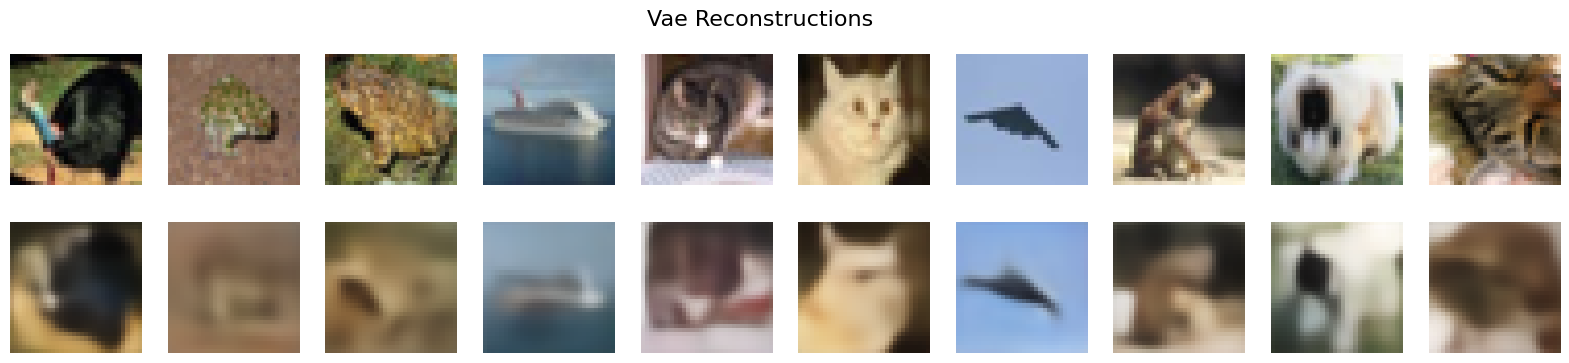

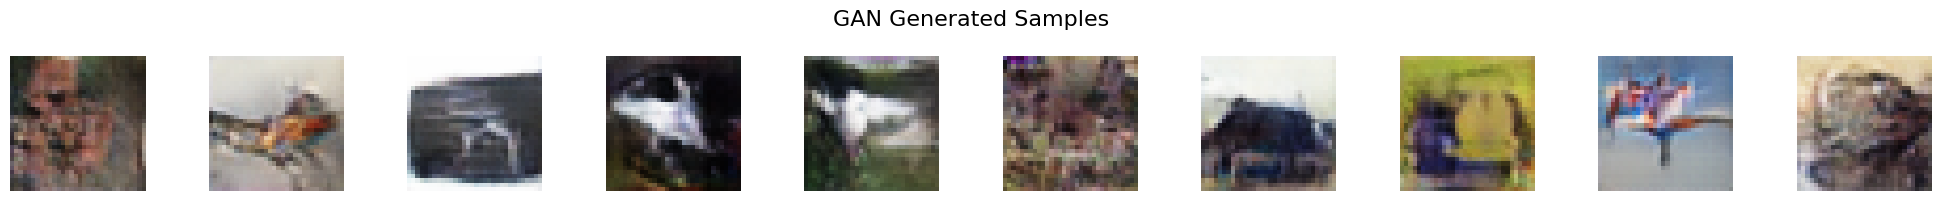

In [117]:
G = Generator32(z_dim=z_dim).to(device)
g_weights = '/home/csalt/Haider/ATML/ATML-PA1/checkpoints_gans/dcgan_cifar10/G_epoch050.pth'
vae = VAE(latent_dim=128, base_ch=64, out_act="tanh").to(device)
vae_weights = '/home/csalt/Haider/ATML/ATML-PA1/checkpoints_vae/vae_epoch050.pth'

## loading the weights into the models
G.load_state_dict(torch.load(g_weights, weights_only=True))
vae.load_state_dict(torch.load(vae_weights, weights_only=True))

G.eval()
vae.eval()

## visualising 10 samples from the test set
show_reconstructions_vae(vae, testset, n=10)

show_samples_gan(G, z_dim=z_dim, n=10, classes=None, device=device)


Key point to note over here is that that vae visualisation are blurry as compared to dcgan visualisations. This is because vae tries to learn the entire distribution of data and hence the samples are more towards the mean of the distribution. However, dcgan just tries to learn to generate realistic images and hence the samples are sharper. The results we get are in line with the theory.

### Evaluating mode collapse

In [ ]:
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

# ------------------------
# ImageNet transforms
# ------------------------
transform = transforms.Compose([
    transforms.Resize(224),  # ResNet expects 224x224 inputs
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet mean
        std=[0.229, 0.224, 0.225]     # ImageNet std
    ),
])

# ------------------------
# Full CIFAR-10 training set (50k)
# ------------------------
trainset_full = torchvision.datasets.CIFAR10(
    root='/home/csalt/Haider/ATML/ATML-PA1/cifar_data',
    train=True, download=True, transform=transform
)

# ------------------------
# Split into train/val
# Example: 45k for train, 5k for validation
# ------------------------
train_size = int(0.9 * len(trainset_full))   # 45k
val_size   = len(trainset_full) - train_size # 5k
trainset, valset = random_split(trainset_full, [train_size, val_size])

trainloader_cifar_imagenet = DataLoader(trainset, batch_size=32, shuffle=True, num_workers=1)
valloader_cifar_imagenet   = DataLoader(valset,   batch_size=32, shuffle=False, num_workers=1)

# ------------------------
# CIFAR-10 test set (10k)
# ------------------------
testset = torchvision.datasets.CIFAR10(
    root='/home/csalt/Haider/ATML/ATML-PA1/cifar_data',
    train=False, download=True, transform=transform
)
testloader_cifar_imagenet = DataLoader(testset, batch_size=32, shuffle=False, num_workers=1)

# ------------------------
# CIFAR-10 classes (for reference)
# ------------------------
classes = ('airplane', 'automobile', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


Files already downloaded and verified
Files already downloaded and verified


In [133]:
import torch
import torch.nn as nn
import torchvision.models as models

# -------------------------
# Build model: ResNet-152 (ImageNet pretrained)
# Fine-tune layer3, layer4, and fc with Adam (no weight decay)
# -------------------------
def build_resnet152_finetune(
    num_classes=10,
    lr_backbone=1e-4,
    lr_fc=1e-3
):
    print("[INFO] Loading ResNet-152 pretrained on ImageNet...")
    try:
        weights = models.ResNet152_Weights.IMAGENET1K_V2
        backbone = models.resnet152(weights=weights)
        print("[INFO] Loaded weights: IMAGENET1K_V2")
    except Exception:
        backbone = models.resnet152(pretrained=True)
        print("[INFO] Loaded weights: legacy pretrained=True")

    # Replace final classification head
    in_feats = backbone.fc.in_features
    backbone.fc = nn.Linear(in_feats, num_classes)
    print(f"[INFO] Replaced final fc layer -> output dim {num_classes}")

    # Freeze everything
    for p in backbone.parameters():
        p.requires_grad = False
    print("[INFO] All layers frozen")

    # Unfreeze only layer3, layer4, and fc
    for p in backbone.layer3.parameters():
        p.requires_grad = True
    for p in backbone.layer4.parameters():
        p.requires_grad = True
    for p in backbone.fc.parameters():
        p.requires_grad = True
    print("[INFO] Unfrozen: layer3, layer4, fc")

    # Adam optimizer with different LRs
    params = [
        {"params": backbone.layer3.parameters(), "lr": lr_backbone},
        {"params": backbone.layer4.parameters(), "lr": lr_backbone},
        {"params": backbone.fc.parameters(),     "lr": lr_fc},
    ]
    optimizer = torch.optim.Adam(params)  # no weight decay
    print(f"[INFO] Optimizer: Adam | LR backbone={lr_backbone}, fc={lr_fc}, no weight decay")

    return backbone, optimizer


In [134]:
import torch
import torch.nn as nn
import os
from tqdm import tqdm

# -------------------------
# Train & Eval loops with tqdm + checkpoint saving
# -------------------------
def train_and_eval(
    model, optimizer,
    trainloader, valloader,
    epochs=20,
    device=None,
    ckpt_dir="./checkpoint_imagenet"
):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    # Ensure checkpoint folder exists
    os.makedirs(ckpt_dir, exist_ok=True)

    best_val_acc = 0.0
    best_path = None

    for epoch in range(1, epochs + 1):
        # ---- Training ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(trainloader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            train_loss = running_loss / total
            train_acc = correct / total
            pbar.set_postfix({"loss": f"{train_loss:.4f}", "acc": f"{train_acc:.4f}"})

        train_loss = running_loss / total
        train_acc = correct / total

        # ---- Validation ----
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        pbar = tqdm(valloader, desc=f"Epoch {epoch}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for imgs, labels in pbar:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                cur_loss = val_loss / max(1, val_total)
                cur_acc = val_correct / max(1, val_total)
                pbar.set_postfix({"loss": f"{cur_loss:.4f}", "acc": f"{cur_acc:.4f}"})

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ---- Print epoch stats ----
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        # Track best val acc and save checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_path = os.path.join(ckpt_dir, f"best_model_epoch{epoch:02d}.pth")
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_acc": val_acc,
            }, best_path)
            print(f"[INFO] Saved new best model to {best_path}")

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    if best_path:
        print(f"Best model weights stored at: {best_path}")
    return model


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build model + optimizer
model, optimizer = build_resnet152_finetune(
    num_classes=10,
    lr_backbone=1e-4,
    lr_fc=1e-3
)

# Train for 20 epochs
trained_model = train_and_eval(
    model, optimizer,
    trainloader_cifar_imagenet, valloader_cifar_imagenet,
    epochs=20,
    device=device
)


[INFO] Loading ResNet-152 pretrained on ImageNet...


[INFO] Loaded weights: IMAGENET1K_V2
[INFO] Replaced final fc layer -> output dim 10
[INFO] All layers frozen
[INFO] Unfrozen: layer3, layer4, fc
[INFO] Optimizer: Adam | LR backbone=0.0001, fc=0.001, no weight decay


Epoch 01/20 | Train Loss: 0.2403, Train Acc: 0.9210 | Val Loss: 0.1216, Val Acc: 0.9594
[INFO] Saved new best model to ./checkpoint_imagenet/best_model_epoch01.pth


KeyboardInterrupt: 

/tmp/ipykernel_82587/2868706283.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


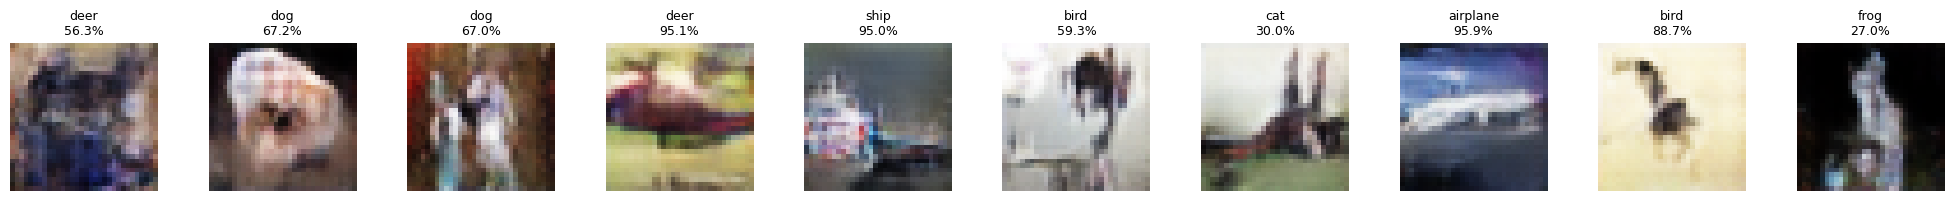

In [141]:
checkpoint = torch.load(
    "checkpoint_imagenet/best_model_epoch01.pth",
    map_location=device
)

trained_model = model
trained_model.load_state_dict(checkpoint["model_state"])



# ------------------------
# Show GAN-generated samples with predictions (ImageNet-normalized for classifier)
# ------------------------
def show_gan_predictions(G, classifier, z_dim, classes, n=10, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    G.to(device).eval()
    classifier.to(device).eval()

    # 1) Sample latent vectors and generate [-1,1] images at 32x32
    z = torch.randn(n, z_dim, device=device)
    with torch.no_grad():
        fakes = G(z)  # [n,3,32,32], range [-1,1]

    # 2) Prepare a copy for classifier: [-1,1] -> [0,1] -> resize -> ImageNet normalize
    fakes_01 = (fakes * 0.5) + 0.5                                       # [0,1]
    fakes_resized = F.interpolate(fakes_01, size=(224, 224),
                                  mode="bilinear", align_corners=False)  # [n,3,224,224]
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
    fakes_imnet = (fakes_resized - mean) / std

    # 3) Classify
    with torch.no_grad():
        logits = classifier(fakes_imnet)
        probs = F.softmax(logits, dim=1)
        confs, preds = probs.max(dim=1)

    # 4) Plot the original GAN images (denormalized to [0,1]) with predictions
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    for i, ax in enumerate(axes):
        img_vis = fakes_01[i].detach().cpu().numpy().transpose(1, 2, 0)  # [H,W,C] in [0,1]
        img_vis = np.clip(img_vis, 0, 1)
        ax.imshow(img_vis)
        ax.axis("off")
        ax.set_title(f"{classes[preds[i]]}\n{confs[i].item()*100:.1f}%", fontsize=9)
    plt.tight_layout()
    plt.show()


show_gan_predictions(G, trained_model, z_dim=128, classes=classes, n=10, device=device)


In [144]:
## running this for the entire test script
import math
import torch
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

# ------------------------------------------------------------
# Quantify GAN diversity with a confidence threshold
# ------------------------------------------------------------
def quantify_gan_diversity(
    generator,            # Generator32 (tanh output in [-1,1], 32x32)
    classifier,           # fine-tuned ResNet-152 expecting ImageNet-normalized 224x224
    classes,              # tuple/list of class names length = 10 for CIFAR-10
    z_dim=128,            # latent dimension (you said 128)
    total_samples=10_000,
    batch_size=256,
    conf_threshold_percent=60,   # only count predictions with >= this confidence
    device=None
):
    """
    Returns:
        counts_dict: {class_name: count_above_threshold, ...}
        summary: dict with totals, acceptance rate, unique classes
    """
    assert len(classes) > 0, "classes list/tuple must be provided"

    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    generator = generator.to(device).eval()
    classifier = classifier.to(device).eval()

    # ImageNet normalization tensors
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

    counts = torch.zeros(len(classes), dtype=torch.long)
    accepted = 0
    seen = 0

    # Progress bar over number of batches
    num_batches = math.ceil(total_samples / batch_size)
    pbar = tqdm(range(num_batches), desc=f"GAN diversity (N={total_samples}, thr={conf_threshold_percent}%)")

    thr = conf_threshold_percent / 100.0

    with torch.no_grad():
        for _ in pbar:
            bsz = min(batch_size, total_samples - seen)
            if bsz <= 0:
                break

            # 1) Sample latent and generate [-1,1] images at 32x32
            z = torch.randn(bsz, z_dim, device=device)
            fakes = generator(z)  # [B,3,32,32], in [-1,1]

            # 2) Prepare for classifier: [-1,1] -> [0,1] -> resize 224 -> ImageNet normalize
            fakes_01 = (fakes * 0.5) + 0.5
            fakes_resized = F.interpolate(fakes_01, size=(224, 224), mode="bilinear", align_corners=False)
            fakes_imnet = (fakes_resized - mean) / std

            # 3) Classify
            logits = classifier(fakes_imnet)
            probs = F.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)  # [B]

            # 4) Apply confidence threshold
            mask = confs >= thr
            if mask.any():
                # Count per class for accepted predictions
                binc = torch.bincount(preds[mask].cpu(), minlength=len(classes))
                counts += binc.to(counts.dtype)

            accepted += int(mask.sum().item())
            seen += bsz

            # Update progress bar postfix
            pbar.set_postfix({
                "accepted": f"{accepted}/{seen}",
                "accpt_rate": f"{(accepted / max(1, seen)) * 100:.1f}%"
            })

    # Prepare outputs
    counts_dict = {classes[i]: int(counts[i].item()) for i in range(len(classes))}
    unique_classes = int((counts > 0).sum().item())
    summary = {
        "total_generated": int(seen),
        "accepted_predictions": int(accepted),
        "rejected_low_confidence": int(seen - accepted),
        "acceptance_rate_percent": (accepted / max(1, seen)) * 100.0,
        "unique_classes_covered": unique_classes
    }

    # Print a concise summary
    print("\nClass counts (>= {:.0f}% confidence):".format(conf_threshold_percent))
    for k, v in sorted(counts_dict.items(), key=lambda kv: (-kv[1], kv[0])):
        print(f"{k:>10s}: {v}")

    print("\nSummary:")
    for k, v in summary.items():
        if isinstance(v, float):
            print(f"- {k}: {v:.2f}")
        else:
            print(f"- {k}: {v}")

    return counts_dict, summary


# ------------------------------------------------------------
# Example usage
# Assumes you already have:
#   - G: loaded Generator32 with z_dim=128
#   - trained_model: your fine-tuned ResNet-152 classifier
#   - classes: CIFAR-10 class names
#   - device: torch.device(...)
# ------------------------------------------------------------
counts, summary = quantify_gan_diversity(
    generator=G,
    classifier=trained_model,
    classes=classes,
    z_dim=128,
    total_samples=10_000,
    batch_size=64,
    conf_threshold_percent=50,
    device=device
)



GAN diversity (N=10000, thr=50%): 100%|██████████| 157/157 [00:09<00:00, 16.60it/s, accepted=7378/10000, accpt_rate=73.8%]


Class counts (>= 50% confidence):
      bird: 1526
      ship: 1289
  airplane: 1045
      frog: 986
      deer: 916
     horse: 503
       cat: 452
     truck: 244
       dog: 243
automobile: 174

Summary:
- total_generated: 10000
- accepted_predictions: 7378
- rejected_low_confidence: 2622
- acceptance_rate_percent: 73.78
- unique_classes_covered: 10


### Fréchet Inception Distance

In [149]:


# =========================
# Inception-V3 feature extractor (pool3 = 2048-D)
# =========================
def build_inception_pool3(device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    weights = models.Inception_V3_Weights.IMAGENET1K_V1

    # aux_logits must be True for these weights (aux head is constructed but ignored in eval)
    net = models.inception_v3(weights=weights, aux_logits=True).to(device).eval()

    # Hook on avgpool to get 2048-D pool3 features
    feat = {}
    def hook_fn(module, inputs, output):
        feat["pool3"] = torch.flatten(output, 1)  # [B, 2048]

    net.avgpool.register_forward_hook(hook_fn)
    return net, feat

# =========================
# Preprocessing for Inception:
# input tensors expected in [-1,1] 32x32 (GAN/VAE/CIFAR as given)
# map -> [0,1], resize to 299, normalize with ImageNet mean/std
# =========================
def preprocess_for_inception(x, device):
    # x: [B,3,H,W] in [-1,1]
    x = (x * 0.5) + 0.5  # -> [0,1]
    if x.shape[-1] != 299:
        x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
    x = (x - mean) / std
    return x

# =========================
# Feature extraction helpers
# =========================
@torch.no_grad()
def inception_features_of_dataset(dataloader, inception, hook_dict, device):
    feats = []
    for imgs, _ in tqdm(dataloader, desc="Inception feats: real test"):
        imgs = imgs.to(device)                         # [-1,1], 32x32
        x = preprocess_for_inception(imgs, device)     # -> normalized 299x299
        _ = inception(x)                               # hook fills hook_dict["pool3"]
        feats.append(hook_dict["pool3"].detach().cpu())
    feats = torch.cat(feats, dim=0).numpy()            # [N, 2048]
    return feats

@torch.no_grad()
def inception_features_of_vae_recons(vae, dataloader, inception, hook_dict, device):
    vae.eval()
    feats = []
    for imgs, _ in tqdm(dataloader, desc="Inception feats: VAE recon"):
        imgs = imgs.to(device)                         # [-1,1], 32x32
        recons, _, _ = vae(imgs)                       # [-1,1], 32x32
        x = preprocess_for_inception(recons, device)
        _ = inception(x)
        feats.append(hook_dict["pool3"].detach().cpu())
    feats = torch.cat(feats, dim=0).numpy()
    return feats

@torch.no_grad()
def inception_features_of_gan(G, z_dim, total_samples, batch_size, inception, hook_dict, device):
    G.eval()
    feats = []
    n_batches = math.ceil(total_samples / batch_size)
    done = 0
    pbar = tqdm(range(n_batches), desc=f"Inception feats: GAN (N={total_samples})")
    for _ in pbar:
        bsz = min(batch_size, total_samples - done)
        if bsz <= 0:
            break
        z = torch.randn(bsz, z_dim, device=device)
        fakes = G(z)                                   # [-1,1], 32x32
        x = preprocess_for_inception(fakes, device)
        _ = inception(x)
        feats.append(hook_dict["pool3"].detach().cpu())
        done += bsz
    feats = torch.cat(feats, dim=0).numpy()
    return feats

# =========================
# Stats and FID
# =========================
def compute_stats(feats: np.ndarray):
    mu = feats.mean(axis=0)
    sigma = np.cov(feats, rowvar=False)
    return mu, sigma

def trace_sqrt_product(sigma_r: np.ndarray, sigma_g: np.ndarray, eps=1e-6):
    """
    Compute Tr( (sigma_r^{1/2} sigma_g sigma_r^{1/2})^{1/2} )
    via eigen-decomposition of a symmetric PSD matrix.
    """
    # Regularize to improve numerical stability
    sigma_r = sigma_r + np.eye(sigma_r.shape[0]) * eps
    sigma_g = sigma_g + np.eye(sigma_g.shape[0]) * eps

    # Sigma_r^{1/2}
    evals_r, evecs_r = np.linalg.eigh(sigma_r)
    evals_r_clamped = np.clip(evals_r, a_min=0.0, a_max=None)
    sqrt_r = (evecs_r @ np.diag(np.sqrt(evals_r_clamped)) @ evecs_r.T)

    # A = sqrt_r * sigma_g * sqrt_r  (symmetric PSD)
    A = sqrt_r @ sigma_g @ sqrt_r

    # eigenvalues of A
    evals_A, _ = np.linalg.eigh(A)
    evals_A_clamped = np.clip(evals_A, a_min=0.0, a_max=None)
    trace_sqrt = np.sum(np.sqrt(evals_A_clamped))
    return trace_sqrt

def fid(mu_r, sigma_r, mu_g, sigma_g):
    diff = mu_r - mu_g
    diff_sq = diff.dot(diff)
    tr_sr = np.trace(sigma_r)
    tr_sg = np.trace(sigma_g)
    tr_sqrt = trace_sqrt_product(sigma_r, sigma_g)
    return float(diff_sq + tr_sr + tr_sg - 2.0 * tr_sqrt)

# =========================
# Orchestrator
# =========================
def compute_fids(G, vae, testloader, z_dim=128, gan_N=10_000, gan_batch=256, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inception, hook = build_inception_pool3(device)

    # Real test features
    feats_real = inception_features_of_dataset(testloader, inception, hook, device)
    mu_r, sig_r = compute_stats(feats_real)

    # VAE recon features
    feats_vae = inception_features_of_vae_recons(vae, testloader, inception, hook, device)
    mu_vae, sig_vae = compute_stats(feats_vae)
    fid_vae = fid(mu_r, sig_r, mu_vae, sig_vae)

    # GAN features (10k)
    feats_gan = inception_features_of_gan(G, z_dim, gan_N, gan_batch, inception, hook, device)
    mu_gan, sig_gan = compute_stats(feats_gan)
    fid_gan = fid(mu_r, sig_r, mu_gan, sig_gan)

    print("\n=== FID results (lower is better) ===")
    print(f"FID(VAE recon vs. test): {fid_vae:.3f}")
    print(f"FID(GAN  {gan_N} vs. test): {fid_gan:.3f}")

    return {
        "fid_vae_vs_test": fid_vae,
        "fid_gan_vs_test": fid_gan,
        "mu_test": mu_r, "sigma_test": sig_r,
        "mu_vae": mu_vae, "sigma_vae": sig_vae,
        "mu_gan": mu_gan, "sigma_gan": sig_gan,
    }


results = compute_fids(G, vae, testloader_cifar, z_dim=128, gan_N=10_000, gan_batch=256, device=device)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/csalt/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:50<00:00, 2.16MB/s] 
Inception feats: GAN (N=10000): 100%|██████████| 40/40 [00:04<00:00,  8.19it/s]



=== FID results (lower is better) ===
FID(VAE recon vs. test): 132.656
FID(GAN  10000 vs. test): 35.648


## Latent Space Structure

### Interpolation

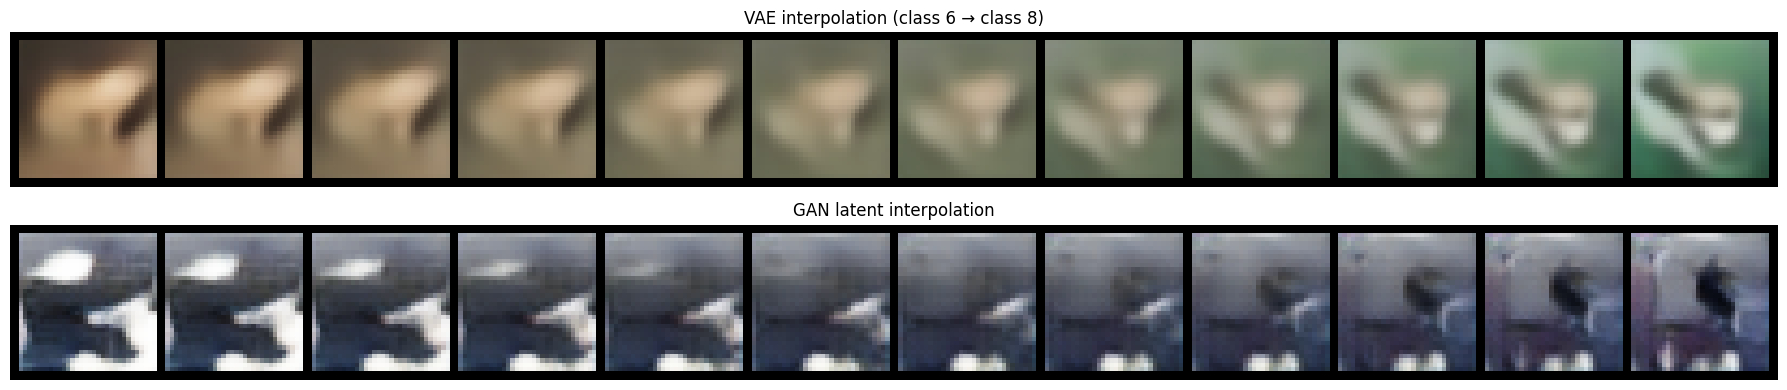

In [151]:
import torch
import torch.nn.functional as F
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Helpers
# -------------------------------------------------------

@torch.no_grad()
def pick_two_test_images_with_diff_labels(testloader, device):
    """Return (x1, x2, y1, y2) with y1 != y2."""
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        B = labels.size(0)
        for _ in range(20):
            i = torch.randint(0, B, (1,)).item()
            j = torch.randint(0, B, (1,)).item()
            if labels[i].item() != labels[j].item():
                return imgs[i:i+1], imgs[j:j+1], labels[i].item(), labels[j].item()
    raise RuntimeError("Could not find two different labels in test set.")

def interpolate(z1, z2, n_points=10):
    """Linear interpolation including endpoints."""
    alphas = torch.linspace(0, 1, steps=n_points+2, device=z1.device)
    return torch.stack([(1-a)*z1 + a*z2 for a in alphas], dim=0)

@torch.no_grad()
def ensure_distinct_gan_latents(G, z_dim, device, max_tries=20, mse_thr=0.02):
    """Find z1, z2 such that G(z1), G(z2) are not nearly identical."""
    for _ in range(max_tries):
        z1 = torch.randn(1, z_dim, device=device)
        z2 = torch.randn(1, z_dim, device=device)
        x1, x2 = G(z1).clamp(-1,1), G(z2).clamp(-1,1)
        if F.mse_loss(x1, x2).item() >= mse_thr:
            return z1, z2, x1, x2
    return z1, z2, x1, x2

def to_grid(imgs):
    """Convert [-1,1] images to a grid in [0,1]."""
    imgs_01 = (imgs.clamp(-1,1) * 0.5) + 0.5
    return vutils.make_grid(imgs_01, nrow=imgs.shape[0], padding=2)

# -------------------------------------------------------
# Interpolation routine
# -------------------------------------------------------

@torch.no_grad()
def visualize_interpolations(vae, G, testloader, z_dim=128, n_points=10, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ---- VAE interpolation ----
    x1, x2, y1, y2 = pick_two_test_images_with_diff_labels(testloader, device)
    mu1, logvar1 = vae.encoder(x1)
    mu2, logvar2 = vae.encoder(x2)
    z1, z2 = mu1[0], mu2[0]

    zs_vae = interpolate(z1, z2, n_points)
    imgs_vae = vae.decoder(zs_vae).clamp(-1,1)

    # ---- GAN interpolation ----
    z1_g, z2_g, _, _ = ensure_distinct_gan_latents(G, z_dim, device)
    zs_gan = interpolate(z1_g[0], z2_g[0], n_points)
    imgs_gan = G(zs_gan).clamp(-1,1)

    # ---- Plot ----
    grid_vae = to_grid(imgs_vae)
    grid_gan = to_grid(imgs_gan)

    fig, axes = plt.subplots(2, 1, figsize=(2*(n_points+2), 4))
    axes[0].imshow(grid_vae.permute(1,2,0).cpu().numpy())
    axes[0].axis("off")
    axes[0].set_title(f"VAE interpolation (class {y1} → class {y2})")

    axes[1].imshow(grid_gan.permute(1,2,0).cpu().numpy())
    axes[1].axis("off")
    axes[1].set_title("GAN latent interpolation")

    plt.tight_layout()
    plt.show()

# -------------------------------------------------------
# Example usage (assuming you already have a trained VAE, GAN, CIFAR testloader, and device)
# -------------------------------------------------------
visualize_interpolations(vae, G, testloader_cifar, z_dim=128, n_points=10, device=device)


### Latent Representation Analysis

/home/csalt/anaconda3/envs/allm/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.218s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 1.505937
[t-SNE] KL divergence after 250 iterations with early exaggeration: 95.188278
[t-SNE] KL divergence after 1000 iterations: 4.145770


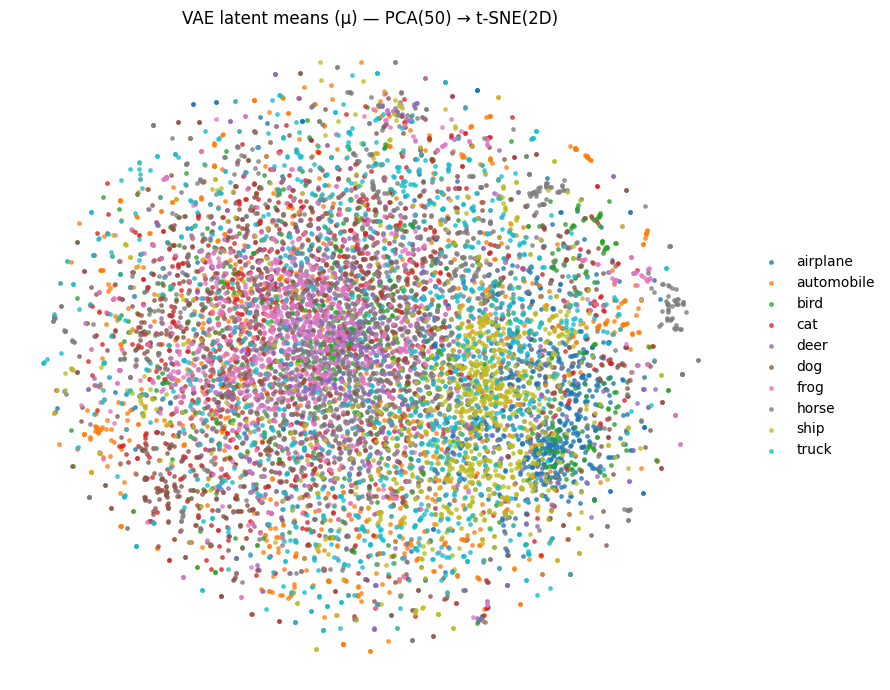

In [153]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# --------------------------
# 1) Collect latent means μ
# --------------------------
@torch.no_grad()
def collect_latent_means(vae, testloader, device):
    vae.eval()
    Z, Y = [], []
    for imgs, labels in testloader:
        imgs = imgs.to(device)
        mu, _ = vae.encoder(imgs)   # [B, d]
        Z.append(mu.detach().cpu())
        Y.append(labels.detach().cpu())
    Z = torch.cat(Z, dim=0).numpy().astype(np.float32)  # [N, d]
    Y = torch.cat(Y, dim=0).numpy()                     # [N]
    return Z, Y

# --------------------------
# 2) PCA (→ 50D) then t-SNE (→ 2D)
# --------------------------
def pca50_then_tsne2(Z, tsne_perplexity=30, tsne_iter=1000, tsne_init='pca', tsne_lr='auto'):
    n_comp = min(50, Z.shape[1])  # if latent_dim < 50, cap at latent_dim
    pca = PCA(n_components=n_comp, svd_solver='auto', whiten=False)
    Z_pca50 = pca.fit_transform(Z)             # [N, min(50, d)]

    tsne = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        n_iter=tsne_iter,
        init=tsne_init,
        learning_rate=tsne_lr,
        metric='euclidean',
        verbose=1,
        # random_state=<int>  # set for reproducibility if desired
    )
    Z_tsne2 = tsne.fit_transform(Z_pca50)      # [N, 2]
    return Z_tsne2

# --------------------------
# 3) Single visualization (t-SNE)
# --------------------------
CIFAR10_NAMES = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

def scatter_tsne(Z2, Y, title="VAE latent means (μ) — PCA(50) → t-SNE(2D)", figsize=(9, 7), alpha=0.7, s=6):
    plt.figure(figsize=figsize)
    cmap = plt.get_cmap('tab10')
    for cls in range(10):
        idx = (Y == cls)
        plt.scatter(Z2[idx, 0], Z2[idx, 1], s=s, alpha=alpha, color=cmap(cls), label=CIFAR10_NAMES[cls])
    plt.title(title)
    plt.axis('off')
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

# --------------------------
# Orchestrator
# --------------------------
def analyze_vae_latents_tsne(vae, testloader, device,
                             tsne_perplexity=30, tsne_iter=1000, tsne_init='pca', tsne_lr='auto',
                             save_npz_path=None):
    # 1) Collect μ
    Z, Y = collect_latent_means(vae, testloader, device)   # Z: [10000, d], Y: [10000]

    # 2) PCA(→50) then t-SNE(→2)
    Z_tsne2 = pca50_then_tsne2(Z,
                               tsne_perplexity=tsne_perplexity,
                               tsne_iter=tsne_iter,
                               tsne_init=tsne_init,
                               tsne_lr=tsne_lr)

    # Optional save
    if save_npz_path is not None:
        np.savez_compressed(save_npz_path, Z=Z, Y=Y, Z_tsne2=Z_tsne2)

    # 3) Single visualization
    scatter_tsne(Z_tsne2, Y)

# --------------------------
# Run
# --------------------------
# Example call (uses entire CIFAR-10 test set already loaded):
analyze_vae_latents_tsne(
    vae, testloader_cifar, device,
    tsne_perplexity=30, tsne_iter=1000, tsne_init='pca', tsne_lr='auto',
    save_npz_path="./vae_test_latents_cifar10_tsne.npz"
)


### Semantic Factors

In [155]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np
from typing import List, Tuple, Optional

# -------------------------------------------------------
# Utilities
# -------------------------------------------------------

def _to01(x):
    # [-1,1] -> [0,1] for display
    return (x.clamp(-1, 1) * 0.5) + 0.5

@torch.no_grad()
def _pick_random_test_image(testloader, device):
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        i = torch.randint(0, imgs.size(0), (1,)).item()
        return imgs[i:i+1], int(labels[i].item())
    raise RuntimeError("Empty testloader.")

@torch.no_grad()
def _decode(vae, z):
    if hasattr(vae, "decoder"):
        return vae.decoder(z)
    elif hasattr(vae, "decode"):
        return vae.decode(z)
    else:
        raise AttributeError("VAE must expose .decoder(z) or .decode(z).")

# -------------------------------------------------------
# Core: measure effect size per latent dimension
# -------------------------------------------------------

@torch.no_grad()
def measure_dimension_effects(
    vae,
    img_1x3xHxW: torch.Tensor,
    steps: int = 7,
    k_sigma: float = 3.0,
    device: Optional[torch.device] = None,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Returns:
      mu [D], sigma [D], effects [D], x_base [1,3,H,W]
    where effects[d] = mean over steps of MSE( decode(z with z_d swept), decode(mu) ).
    """
    vae.eval()
    device = device or img_1x3xHxW.device

    mu, logvar = vae.encoder(img_1x3xHxW)    # [1,D], [1,D]
    mu, logvar = mu[0], logvar[0]            # [D], [D]
    sigma = torch.exp(0.5 * logvar)          # [D]

    # Baseline decode at z = mu
    x_base = _decode(vae, mu.unsqueeze(0)).clamp(-1, 1)  # [1,3,H,W]

    D = mu.numel()
    effects = torch.zeros(D, device=device)

    # Precompute alphas in [-k_sigma, +k_sigma]
    alphas = torch.linspace(-k_sigma, +k_sigma, steps=steps, device=device)

    for d in range(D):
        # Sweep only dimension d, hold others at mu
        mse_acc = 0.0
        for a in alphas:
            z = mu.clone()
            z[d] = mu[d] + a * sigma[d]
            x = _decode(vae, z.unsqueeze(0)).clamp(-1, 1)
            mse_acc += F.mse_loss(x, x_base, reduction="mean").item()
        effects[d] = mse_acc / float(steps)

    return mu, sigma, effects, x_base

# -------------------------------------------------------
# Traversal visualization for a selected set of dimensions
# -------------------------------------------------------

@torch.no_grad()
def latent_traversal_grid(
    vae,
    mu: torch.Tensor,           # [D]
    sigma: torch.Tensor,        # [D]
    dims: List[int],
    steps: int = 7,
    k_sigma: float = 3.0,
    device: Optional[torch.device] = None,
    title_prefix: str = "",
):
    device = device or mu.device
    alphas = torch.linspace(-k_sigma, +k_sigma, steps=steps, device=device)

    rows = []
    for d in dims:
        imgs_row = []
        for a in alphas:
            z = mu.clone()
            z[d] = mu[d] + a * sigma[d]
            x = _decode(vae, z.unsqueeze(0)).clamp(-1, 1)  # [1,3,H,W]
            imgs_row.append(x)
        row = torch.cat(imgs_row, dim=0)  # [steps,3,H,W]
        rows.append(row)

    grid = torch.cat(rows, dim=0)  # [len(dims)*steps, 3, H, W]
    grid01 = _to01(grid)
    grid_img = vutils.make_grid(grid01, nrow=steps, padding=2)  # rows by steps

    plt.figure(figsize=(2*steps, 2*len(dims)))
    plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy())
    plt.axis("off")
    if title_prefix:
        plt.title(title_prefix)
    # annotate rows with dim indices
    for r, d in enumerate(dims):
        plt.text(
            x=2, y=r*(grid.size(-2)+2)+12,
            s=f"dim {d}",
            color="white", fontsize=10, bbox=dict(facecolor="black", alpha=0.4, pad=2)
        )
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------
# Orchestrator
# -------------------------------------------------------

@torch.no_grad()
def run_latent_traversal_experiment(
    vae,
    testloader,
    device,
    n_dims_to_show: int = 10,
    steps: int = 7,
    k_sigma: float = 3.0,
    select: str = "topk",  # "topk" (by effect) or "random"
    min_effect: float = 0.0,  # ignore dims below this effect when select="topk"
):
    """
    1) pick a random test image, 2) rank dimensions by effect size, 3) show traversals for selected dims,
    4) show bar plot of top-k effect sizes.
    """
    img, label = _pick_random_test_image(testloader, device)

    mu, sigma, effects, x_base = measure_dimension_effects(
        vae, img, steps=steps, k_sigma=k_sigma, device=device
    )

    D = mu.numel()
    # selection
    if select == "topk":
        idx_sorted = torch.argsort(effects, descending=True).tolist()
        dims = [d for d in idx_sorted if effects[d].item() >= min_effect][:n_dims_to_show]
        title = f"VAE latent traversal — top-{len(dims)} dims by effect (label {label})"
    elif select == "random":
        perm = torch.randperm(D).tolist()
        dims = perm[:n_dims_to_show]
        title = f"VAE latent traversal — random {len(dims)} dims (label {label})"
    else:
        raise ValueError("select must be 'topk' or 'random'")

    # grid of traversals
    latent_traversal_grid(
        vae, mu, sigma, dims, steps=steps, k_sigma=k_sigma, device=device, title_prefix=title
    )

    # bar chart of top effects (for transparency)
    topk = min(max(n_dims_to_show, 20), D)
    idx_top = torch.argsort(effects, descending=True)[:topk]
    vals = effects[idx_top].cpu().numpy()
    labs = [f"d{int(i)}" for i in idx_top.cpu().tolist()]

    plt.figure(figsize=(max(8, 0.35*topk), 4))
    plt.bar(np.arange(topk), vals)
    plt.xticks(np.arange(topk), labs, rotation=90)
    plt.ylabel("mean MSE vs baseline over sweep")
    plt.title("Most sensitive latent dimensions (higher = larger visual change)")
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------
# Run (example)
# -------------------------------------------------------
# Choose one:
#   select="topk"  -> shows the most visually influential dims (recommended)
#   select="random"-> random dims to audit interpretability more broadly
# run_latent_traversal_experiment(
#     vae,
#     testloader_cifar,
#     device,
#     n_dims_to_show=10,
#     steps=7,
#     k_sigma=3.0,
#     select="topk",
#     min_effect=0.0
# )


## Out of Distribution Analysis

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# ------------------------
# Transform: normalize to [-1,1]
# ------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# ------------------------
# CIFAR-10 test set (10k)
# ------------------------
cifar10_test = torchvision.datasets.CIFAR10(
    root='/home/csalt/Haider/ATML/ATML-PA1/cifar_data',
    train=False, download=True, transform=transform
)
testloader_cifar = DataLoader(cifar10_test, batch_size=32, shuffle=False, num_workers=1)

# ------------------------
# CIFAR-100 test set (10k)
# ------------------------
cifar100_test = torchvision.datasets.CIFAR100(
    root='/home/csalt/Haider/ATML/ATML-PA1/cifar100_data',  # separate folder
    train=False, download=True, transform=transform
)
testloader_cifar100 = DataLoader(cifar100_test, batch_size=32, shuffle=False, num_workers=1)

# ------------------------
# Evaluation function
# ------------------------
@torch.no_grad()
def eval_vae_on_loader(vae, loader, device):
    """
    Returns (mean_MSE_per_image, mean_KL_per_image).
    MSE computed with decode(mu) (deterministic).
    KL = 0.5 * sum(mu^2 + sigma^2 - log sigma^2 - 1) per sample.
    """
    vae.eval()
    mse_sum = 0.0
    kl_sum  = 0.0
    n = 0
    for imgs, _ in loader:
        imgs = imgs.to(device)
        mu, logvar = vae.encoder(imgs)                 # [B, D], [B, D]
        recons = vae.decoder(mu).clamp(-1, 1)          # decode mean latent; outputs in [-1,1]

        # Per-sample MSE
        mse = F.mse_loss(recons, imgs, reduction='none') \
                .view(imgs.size(0), -1).mean(dim=1)    # [B]
        # Per-sample KL
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)  # [B]

        mse_sum += mse.sum().item()
        kl_sum  += kl.sum().item()
        n       += imgs.size(0)

    return mse_sum / n, kl_sum / n

# ------------------------
# Run evaluation
# ------------------------
print(f"CIFAR-10 test samples:  {len(cifar10_test)}")
print(f"CIFAR-100 test samples: {len(cifar100_test)}")

mse10,  kl10  = eval_vae_on_loader(vae, testloader_cifar,    device)
mse100, kl100 = eval_vae_on_loader(vae, testloader_cifar100, device)

print(f"CIFAR-10  test: MSE = {mse10:.6f} | KL = {kl10:.6f}")
print(f"CIFAR-100 test: MSE = {mse100:.6f} | KL = {kl100:.6f}")


Files already downloaded and verified


 74%|███████▍  | 125M/169M [38:02<21:07, 34.6kB/s]   